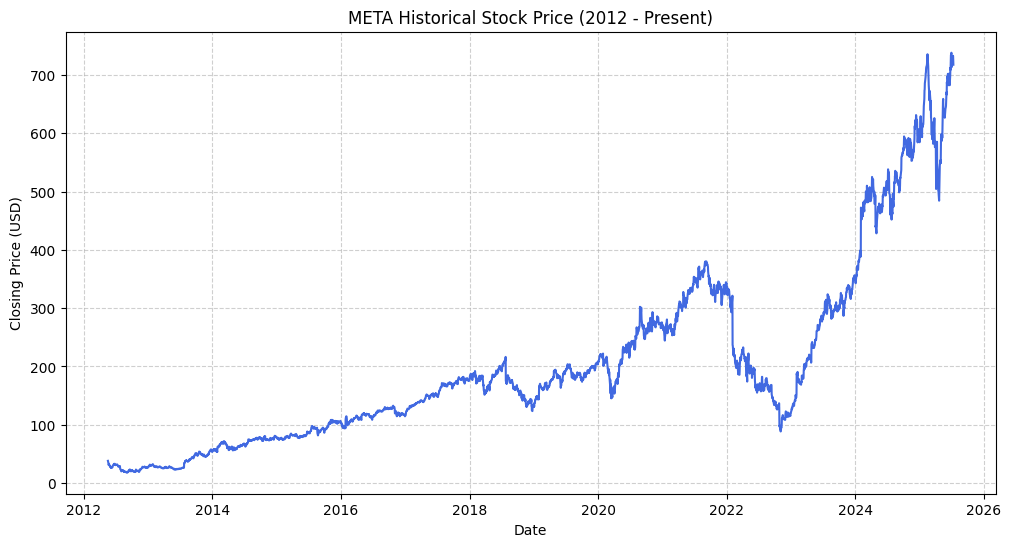


Model Accuracy: 51.15%

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.60      0.53       301
           1       0.56      0.43      0.49       350

    accuracy                           0.51       651
   macro avg       0.52      0.52      0.51       651
weighted avg       0.52      0.51      0.51       651



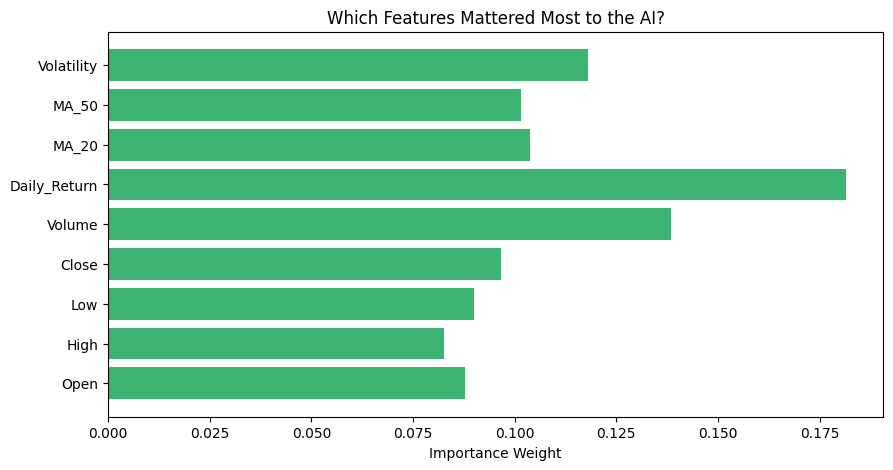

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. LOAD DATA
file_path = '/content/META_things.csv'
df = pd.read_csv(file_path)

# Standardize column name 'date' to 'Date'
if 'date' in df.columns:
    df.rename(columns={'date': 'Date'}, inplace=True)

# 2. DATE PREPROCESSING & PLOT
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Plot historical closing prices with accurate dates on X-axis
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], color='royalblue')
plt.title('META Historical Stock Price (2012 - Present)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. FEATURE ENGINEERING
df['Daily_Return'] = df['Close'].pct_change()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

# Target: 1 if next day's Close is higher, 0 if lower/same
df['Next_Day_Close'] = df['Close'].shift(-1)
df['Target'] = np.where(df['Next_Day_Close'] > df['Close'], 1, 0)

# Drop missing values
df.dropna(inplace=True)

# 4. TRAIN / TEST SPLIT (Sequential Time-Series Split)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'Volatility']
X = df[features]
y = df['Target']

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 5. MODEL TRAINING & EVALUATION
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, predictions))

# 6. FEATURE IMPORTANCE VISUALIZATION
importance = model.feature_importances_
plt.figure(figsize=(10, 5))
plt.barh(features, importance, color='mediumseagreen')
plt.title('Which Features Mattered Most to the AI?')
plt.xlabel('Importance Weight')
plt.show()